In [ ]:
import pandas as pd
import os
from datetime import datetime
import matplotlib.pyplot as plt
#!pip install --upgrade pip
#!python3 -m pip install calender
#import calender


### combile all files into one dataframe and save into a csv file

In [ ]:
jan = pd.read_csv("Data/Sales_January_2019.csv")
jan.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,141234,iPhone,1,700,01/22/19 21:25,"944 Walnut St, Boston, MA 02215"
1,141235,Lightning Charging Cable,1,14.95,01/28/19 14:15,"185 Maple St, Portland, OR 97035"
2,141236,Wired Headphones,2,11.99,01/17/19 13:33,"538 Adams St, San Francisco, CA 94016"
3,141237,27in FHD Monitor,1,149.99,01/05/19 20:33,"738 10th St, Los Angeles, CA 90001"
4,141238,Wired Headphones,1,11.99,01/25/19 11:59,"387 10th St, Austin, TX 73301"


In [ ]:
this_directory = os.getcwd()
data_directory = os.path.join(this_directory, "Data")
sales = pd.DataFrame()

for file in os.listdir(data_directory):
    file_path = os.path.join(data_directory, file)
    df = pd.read_csv(file_path)
    sales = pd.concat([sales, df], ignore_index = True)

sales.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
1,NaN,NaN,NaN,NaN,NaN,NaN
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"


In [ ]:
sales.shape

(186850, 6)

In [ ]:
sales.to_csv("all_sales.csv", index = False)

In [ ]:
all_sales = pd.read_csv("all_sales.csv")
all_sales.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
1,NaN,NaN,NaN,NaN,NaN,NaN
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"


### data cleaning

#### drop NaN rows

In [ ]:
all_sales.dropna(how = "all", inplace = True)
all_sales.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
5,176561,Wired Headphones,1,11.99,04/30/19 09:27,"333 8th St, Los Angeles, CA 90001"


In [ ]:
all_sales.shape

(186305, 6)

In [ ]:
#There are some rows with column names
all_sales = all_sales[all_sales['Order Date'] != 'Order Date']
all_sales.shape

(185950, 6)

In [ ]:
all_sales.drop_duplicates(inplace = True)
all_sales.shape

(185686, 6)

In [ ]:
all_sales.info()

<class 'pandas.core.frame.DataFrame'>
Index: 185686 entries, 0 to 186849
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Order ID          185686 non-null  object
 1   Product           185686 non-null  object
 2   Quantity Ordered  185686 non-null  object
 3   Price Each        185686 non-null  object
 4   Order Date        185686 non-null  object
 5   Purchase Address  185686 non-null  object
dtypes: object(6)
memory usage: 9.9+ MB


#### add 'Order Date' column

In [ ]:
all_sales['Order Date'] = pd.to_datetime(all_sales['Order Date'], format = '%m/%d/%y %H:%M')

In [ ]:
all_sales['Order Date'].dt.month

0         4
2         4
3         4
4         4
5         4
         ..
186845    9
186846    9
186847    9
186848    9
186849    9
Name: Order Date, Length: 185686, dtype: int32

In [ ]:
type(all_sales['Order Date'].iloc[0].month)

int

In [ ]:
all_sales['Month'] = all_sales['Order Date'].dt.month
all_sales.head(2)

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",4
2,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",4


#### convert data 'Quantity Ordered' and 'Price Each' columns to int32 and float respectively

In [ ]:
all_sales['Quantity Ordered'] = all_sales['Quantity Ordered'].astype('int32')
all_sales['Price Each'] = all_sales['Price Each'].astype('float')

#### add city column

In [ ]:
# There are some cities in different state that have same name
all_sales['City'] = all_sales['Purchase Address'].apply(lambda x: x.split(',')[-2] + ' ' + x.split()[-2])
all_sales

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,City
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",4,Dallas TX
2,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",4,Boston MA
3,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,Los Angeles CA
4,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,Los Angeles CA
5,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001",4,Los Angeles CA
...,...,...,...,...,...,...,...,...
186845,259353,AAA Batteries (4-pack),3,2.99,2019-09-17 20:56:00,"840 Highland St, Los Angeles, CA 90001",9,Los Angeles CA
186846,259354,iPhone,1,700.00,2019-09-01 16:00:00,"216 Dogwood St, San Francisco, CA 94016",9,San Francisco CA
186847,259355,iPhone,1,700.00,2019-09-23 07:39:00,"220 12th St, San Francisco, CA 94016",9,San Francisco CA
186848,259356,34in Ultrawide Monitor,1,379.99,2019-09-19 17:30:00,"511 Forest St, San Francisco, CA 94016",9,San Francisco CA


#### add hour column

In [ ]:
all_sales['Hour'] = all_sales['Order Date'].dt.hour
all_sales.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,City,Hour
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",4,Dallas TX,8
2,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",4,Boston MA,22
3,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,Los Angeles CA,14
4,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,Los Angeles CA,14
5,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001",4,Los Angeles CA,9


### EDA (Exploratory Data Analysis)

#### get the month of maximum sales

In [ ]:
monthly_sales = all_sales.groupby(['Month']).apply(lambda x: ( (x['Quantity Ordered']) * (x['Price Each']) ).sum() )
monthly_sales = monthly_sales.reset_index()
monthly_sales.rename(columns = {0:'Revenue'}, inplace = True)
monthly_sales

,Month,Revenue
0,1,1821413.16
1,2,2200078.08
2,3,2804973.35
3,4,3389217.98
4,5,3150616.23
5,6,2576280.15
6,7,2646461.32
7,8,2241083.37
8,9,2094465.69
9,10,3734777.86


In [ ]:
monthly_sales['Month Name'] = monthly_sales['Month'].apply(lambda x: datetime(2019, x, 1).strftime('%B'))
monthly_sales.sort_values(by = 'Revenue', ascending = False, inplace = True)
monthly_sales

,Month,Revenue,Month Name
11,12,4608295.70,December
9,10,3734777.86,October
3,4,3389217.98,April
10,11,3197875.05,November
4,5,3150616.23,May
2,3,2804973.35,March
6,7,2646461.32,July
5,6,2576280.15,June
7,8,2241083.37,August
1,2,2200078.08,February


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, 'December'),
  Text(1, 0, 'October'),
  Text(2, 0, 'April'),
  Text(3, 0, 'November'),
  Text(4, 0, 'May'),
  Text(5, 0, 'March'),
  Text(6, 0, 'July'),
  Text(7, 0, 'June'),
  Text(8, 0, 'August'),
  Text(9, 0, 'February'),
  Text(10, 0, 'September'),
  Text(11, 0, 'January')])

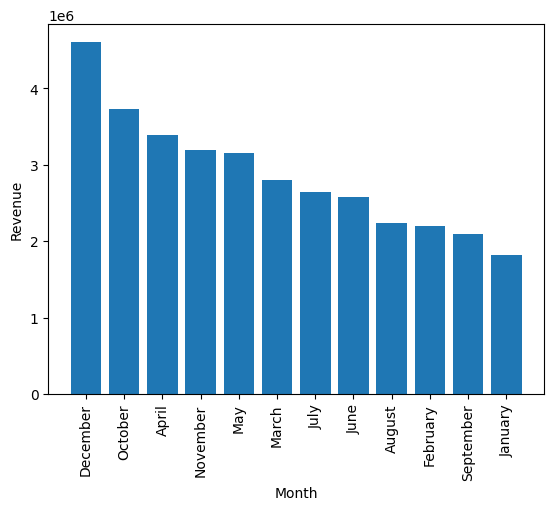

In [ ]:
plt.bar(monthly_sales['Month Name'], monthly_sales['Revenue'])
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation = 90)

#### get the city with highest number of sales

In [ ]:
city_revenue = all_sales.groupby('City').apply(lambda x: ((x['Price Each']) * (x['Quantity Ordered'])).sum())
city_revenue.sort_values(ascending = False)

City
 San Francisco CA    8254743.55
 Los Angeles CA      5448304.28
 New York City NY    4661867.14
 Boston MA           3658627.65
 Atlanta GA          2794199.07
 Dallas TX           2765373.96
 Seattle WA          2745046.02
 Portland OR         1870010.56
 Austin TX           1818044.33
 Portland ME          449321.38
dtype: float64

(array([      0., 1000000., 2000000., 3000000., 4000000., 5000000.,
        6000000., 7000000., 8000000., 9000000.]),
 [Text(0.0, 0, '0'),
  Text(1000000.0, 0, '1'),
  Text(2000000.0, 0, '2'),
  Text(3000000.0, 0, '3'),
  Text(4000000.0, 0, '4'),
  Text(5000000.0, 0, '5'),
  Text(6000000.0, 0, '6'),
  Text(7000000.0, 0, '7'),
  Text(8000000.0, 0, '8'),
  Text(9000000.0, 0, '9')])

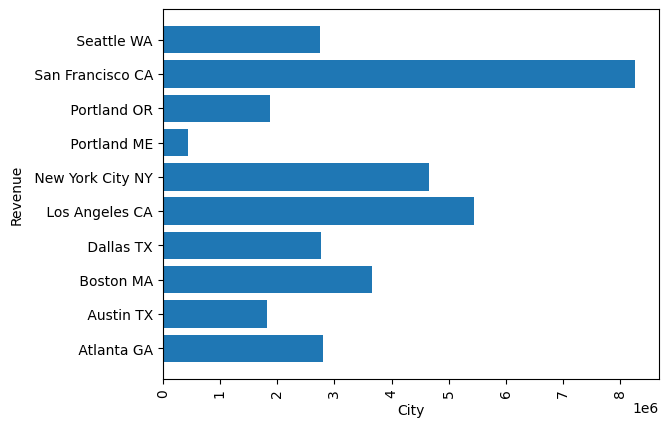

In [ ]:
plt.barh(city_revenue.index, city_revenue.values)
plt.xlabel('City')
plt.ylabel('Revenue')
plt.xticks(rotation = 90)

### what time should we display advertisement to maximize likelihood of cusomer buying a product

In [ ]:
hourly_sales = all_sales.groupby('Hour')['Hour'].count()
hourly_sales.sort_values(ascending = False)

Hour
19    12886
12    12573
11    12392
18    12263
20    12218
13    12115
14    10965
10    10929
21    10905
17    10884
16    10359
15    10159
22     8808
9      8740
23     6262
8      6252
7      4002
0      3902
6      2481
1      2347
5      1320
2      1242
4       852
3       830
Name: Hour, dtype: int64

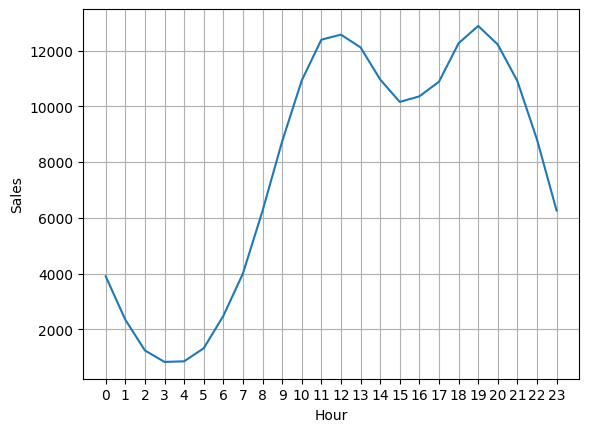

In [ ]:
plt.plot(hourly_sales.index, hourly_sales.values)
plt.xlabel('Hour')
plt.ylabel('Sales')
plt.xticks(hourly_sales.index)
plt.grid()

### find which items are bought frequently

In [ ]:
#later got to know same items bought togather have same order id :)
product_groups = all_sales.groupby(['Purchase Address', 'Order Date']).agg({'Product': lambda x: sorted(tuple(x)), 'Quantity Ordered': min}).reset_index()
product_groups = product_groups[product_groups['Product'].apply(lambda x: len(x) > 1)]
product_groups

/tmp/ipykernel_290/770349660.py:2: FutureWarning: The provided callable <built-in function min> is currently using SeriesGroupBy.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  product_groups = all_sales.groupby(['Purchase Address', 'Order Date']).agg({'Product': lambda x: sorted(tuple(x)), 'Quantity Ordered': min}).reset_index()


,Purchase Address,Order Date,Product,Quantity Ordered
10,"1 14th St, Portland, OR 97035",2019-10-16 15:11:00,"[Macbook Pro Laptop, USB-C Charging Cable]",1
35,"1 9th St, New York City, NY 10001",2019-05-10 14:50:00,"[Lightning Charging Cable, iPhone]",1
39,"1 Adams St, Austin, TX 73301",2019-04-12 06:16:00,"[Google Phone, USB-C Charging Cable]",1
70,"1 Hickory St, Atlanta, GA 30301",2019-04-14 23:36:00,"[Lightning Charging Cable, Wired Headphones, i...",1
76,"1 Highland St, Boston, MA 02215",2019-06-10 21:38:00,"[Wired Headphones, iPhone]",1
...,...,...,...,...
178355,"999 Jefferson St, Portland, OR 97035",2019-07-06 15:00:00,"[Bose SoundSport Headphones, Google Phone]",1
178356,"999 Johnson St, San Francisco, CA 94016",2019-11-11 19:50:00,"[Lightning Charging Cable, USB-C Charging Cable]",1
178360,"999 Lakeview St, Austin, TX 73301",2019-09-07 02:09:00,"[Google Phone, USB-C Charging Cable]",1
178375,"999 Main St, San Francisco, CA 94016",2019-07-03 17:42:00,"[AAA Batteries (4-pack), iPhone]",1


In [ ]:
#as lists are not hashable, groupby wont work on column 'Product' hence converting to tuple (tuples with all immutable type elements are hashable)
product_groups['Product'] = product_groups['Product'].apply(tuple)
product_groups_quantity = product_groups.groupby('Product')['Quantity Ordered'].sum()
product_groups_quantity = product_groups_quantity.sort_values(ascending = False).reset_index()
product_groups_quantity

,Product,Quantity Ordered
0,"(Lightning Charging Cable, iPhone)",895
1,"(Google Phone, USB-C Charging Cable)",869
2,"(Wired Headphones, iPhone)",374
3,"(USB-C Charging Cable, Vareebadd Phone)",318
4,"(Google Phone, Wired Headphones)",311
...,...,...
206,"(Apple Airpods Headphones, Google Phone, USB-C...",1
207,"(Apple Airpods Headphones, Bose SoundSport Hea...",1
208,"(Apple Airpods Headphones, Bose SoundSport Hea...",1
209,"(AAA Batteries (4-pack), Lightning Charging Ca...",1


In [ ]:
"""for the entries like (Google Phone, USB-C Charging Cable) and
(Apple Airpods Headphones, Google Phone, USB-C Charging Cable)
we need to incerese count of (Google Phone, USB-C Charging Cable) by same count as
(Apple Airpods Headphones, Google Phone, USB-C Charging Cable)
"""

def refine_count(prod_tuple_to_check, product_groups_quantity):
    count = 0
    prod_tuple_to_check_set = set(prod_tuple_to_check['Product'])
    for _, prod_tuple in product_groups_quantity.iterrows():
        prod_tuple_set = set(prod_tuple['Product'])

        if prod_tuple_to_check_set.issubset(prod_tuple_set) and prod_tuple_to_check_set != prod_tuple_set:
            count += prod_tuple['Quantity Ordered']
    return count

product_groups_quantity['Quantity Ordered'] = product_groups_quantity.apply(lambda x: x['Quantity Ordered'] + refine_count(x, product_groups_quantity), axis = 1)
product_groups_quantity.sort_values(by = 'Quantity Ordered', ascending = False)
product_groups_quantity

,Product,Quantity Ordered
0,"(Lightning Charging Cable, iPhone)",1011
1,"(Google Phone, USB-C Charging Cable)",997
2,"(Wired Headphones, iPhone)",462
3,"(USB-C Charging Cable, Vareebadd Phone)",368
4,"(Google Phone, Wired Headphones)",422
...,...,...
206,"(Apple Airpods Headphones, Google Phone, USB-C...",2
207,"(Apple Airpods Headphones, Bose SoundSport Hea...",1
208,"(Apple Airpods Headphones, Bose SoundSport Hea...",1
209,"(AAA Batteries (4-pack), Lightning Charging Ca...",1


### What product is sold the most

In [ ]:
orders_per_product = all_sales.groupby('Product').agg({'Quantity Ordered':'sum', 'Price Each':'first'}).sort_values(by = 'Quantity Ordered', ascending = False).reset_index()
most_ordered_product = orders_per_product['Product'].iloc[0]
most_ordered_product

'AAA Batteries (4-pack)'

In [ ]:
orders_per_product

,Product,Quantity Ordered,Price Each
0,AAA Batteries (4-pack),30986,2.99
1,AA Batteries (4-pack),27615,3.84
2,USB-C Charging Cable,23931,11.95
3,Lightning Charging Cable,23169,14.95
4,Wired Headphones,20524,11.99
5,Apple Airpods Headphones,15637,150.00
6,Bose SoundSport Headphones,13430,99.99
7,27in FHD Monitor,7541,149.99
8,iPhone,6847,700.00
9,27in 4K Gaming Monitor,6239,389.99


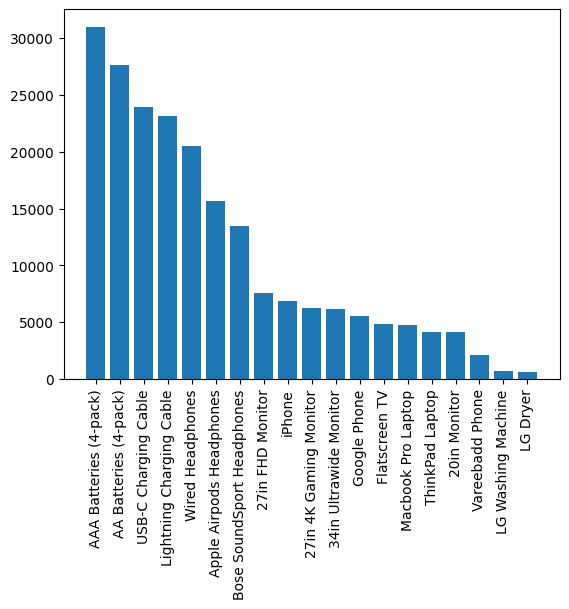

In [ ]:
plt.bar(orders_per_product['Product'], orders_per_product['Quantity Ordered'])
plt.xticks(rotation = 90)
plt.show()

Text(0, 0.5, 'Price Each')

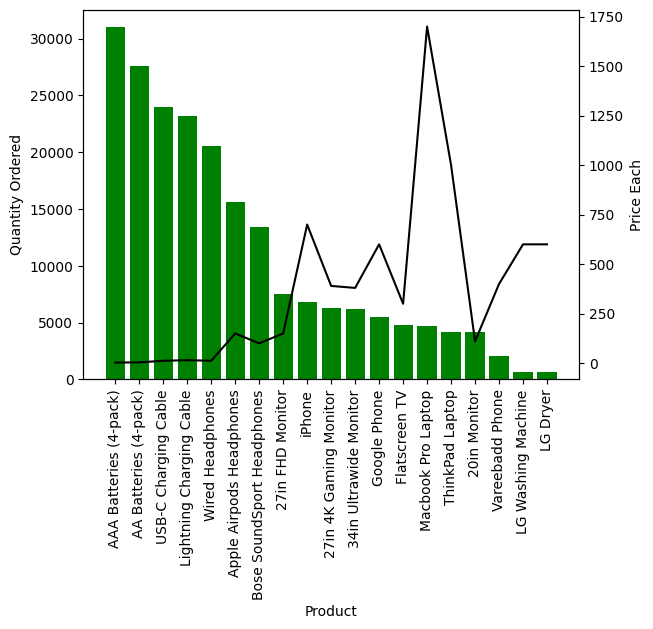

In [ ]:
# may be the number of orders for a product is inversly proportional to price of product
# to back this hypothesis lets overlay price of product graph and orders per product graph
#adding another y-axis

fig, chart1 = plt.subplots()
chart1.bar(orders_per_product['Product'], orders_per_product['Quantity Ordered'], color='green')
chart1.tick_params(axis = 'x', rotation = 90)
chart1.set_xlabel('Product')
chart1.set_ylabel('Quantity Ordered')

chart2 = chart1.twinx()

chart2.plot(orders_per_product['Product'], orders_per_product['Price Each'], color='black')
chart2.set_ylabel('Price Each')

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=0167143f-ef5a-4b78-829d-8a2f5c2222dc' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>